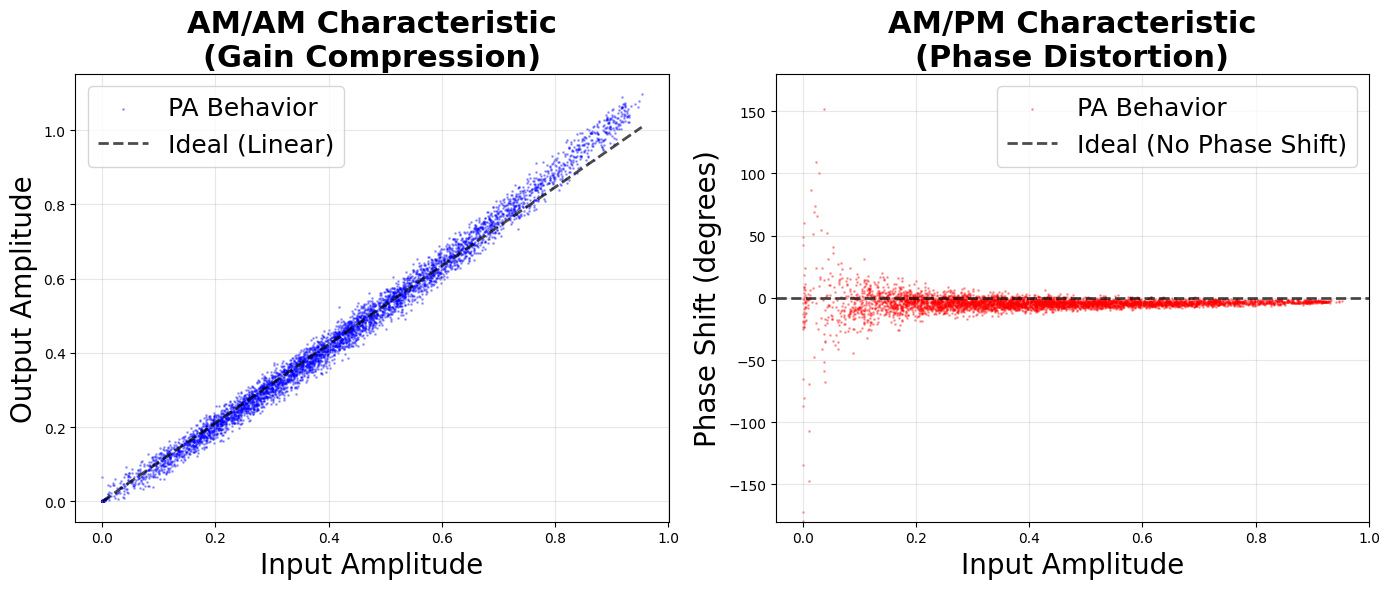


=== PA Characteristic Summary ===
Input amplitude range: 0.0000 to 0.9528
Output amplitude range: 0.0002 to 1.0967
Estimated small-signal gain: 1.0581
Phase distortion range: -348.67° to 1007.68°
80000


In [1]:
from sparseDPD import DataManager, PNTDNN_NeuralNetwork, Volterra, LinearExperiment, AdaptivePruningExperiment

# Load the ideal predistorted signal, and plot
ideal_predistored_dataset = DataManager(num_training_points=50000, num_test_points=5000, num_validaiton_points=5000, filepath='100M_6.5PAPR.mat')

ideal_predistored_dataset.plot_pa_characteristics()

print(len(ideal_predistored_dataset.input_data))

In [2]:
# Print Volterra Performance
volterra_forward_model = Volterra(num_nl_orders=3, num_memory_levels=15, dataset=ideal_predistored_dataset.training_dataset)

print(f" Volterra NMSE: {volterra_forward_model.calculate_volterra_nmse(ideal_predistored_dataset.test_dataset)} dB")

 Volterra NMSE: -41.42440795829603 dB


In [3]:
# Model the ideal predistorted (This will actually be modelled as a forward model)
pntdnn_ideal_predistorted = PNTDNN_NeuralNetwork(num_memory_levels=15, model_type="OneLayerNetwork", forward_model=True)

# train this model
pntdnn_ideal_predistorted.get_best_model(
    num_epochs = 1000,
    training_dataset=ideal_predistored_dataset.training_dataset,
    validation_dataset=ideal_predistored_dataset.validation_dataset
)

# Save the model, so it can be used later
pntdnn_ideal_predistorted.write_nn_to_file(file_path="pntdnn_ideal_predistorted_forward_model.pt")


Using cuda device
Epoch  10/1000  Loss=2.7849e+02  Valid Loss=2.1370e+01  LR=1.00e-03  NMSE=-14.9172 dB
Epoch  20/1000  Loss=6.9865e+01  Valid Loss=4.4676e+00  LR=1.00e-03  NMSE=-21.7144 dB
Epoch  30/1000  Loss=3.1268e+01  Valid Loss=2.0918e+00  LR=1.00e-03  NMSE=-25.0099 dB
Epoch  40/1000  Loss=1.8453e+01  Valid Loss=1.4262e+00  LR=1.00e-03  NMSE=-26.6733 dB
Epoch  50/1000  Loss=1.1852e+01  Valid Loss=1.0103e+00  LR=1.00e-03  NMSE=-28.1707 dB
Epoch  60/1000  Loss=8.1415e+00  Valid Loss=7.3181e-01  LR=1.00e-03  NMSE=-29.5712 dB
Epoch  70/1000  Loss=5.8351e+00  Valid Loss=5.3919e-01  LR=1.00e-03  NMSE=-30.8977 dB
Epoch  80/1000  Loss=4.2966e+00  Valid Loss=4.0277e-01  LR=1.00e-03  NMSE=-32.1646 dB
Epoch  90/1000  Loss=3.2611e+00  Valid Loss=3.0753e-01  LR=1.00e-03  NMSE=-33.3363 dB
Epoch 100/1000  Loss=2.5854e+00  Valid Loss=2.4294e-01  LR=1.00e-03  NMSE=-34.3602 dB
Epoch 110/1000  Loss=2.1505e+00  Valid Loss=1.9719e-01  LR=1.00e-03  NMSE=-35.2663 dB
Epoch 120/1000  Loss=1.8629e+00  Val

Using cuda device

Pruning Iteration 1/10
Pruning 20.0% of remaining weights...
Current pruning: 20.00% of weights are zero
Retraining for 300 epochs...
Epoch  10/300  Loss=3.0291e-01  Valid Loss=2.5402e-02  LR=1.00e-03  NMSE=-44.1664 dB
Epoch  20/300  Loss=2.8405e-01  Valid Loss=2.3557e-02  LR=1.00e-03  NMSE=-44.4940 dB
Epoch  30/300  Loss=2.4948e-01  Valid Loss=2.1048e-02  LR=5.00e-04  NMSE=-44.9832 dB
Epoch  40/300  Loss=2.8249e-01  Valid Loss=2.1568e-02  LR=5.00e-04  NMSE=-44.8770 dB
Epoch  50/300  Loss=2.6527e-01  Valid Loss=2.4403e-02  LR=2.50e-04  NMSE=-44.3408 dB
Epoch  60/300  Loss=2.2446e-01  Valid Loss=2.1494e-02  LR=1.25e-04  NMSE=-44.8920 dB
Epoch  70/300  Loss=2.2091e-01  Valid Loss=2.1208e-02  LR=6.25e-05  NMSE=-44.9503 dB
Epoch  80/300  Loss=2.2077e-01  Valid Loss=2.1621e-02  LR=3.13e-05  NMSE=-44.8665 dB
Epoch  90/300  Loss=2.1909e-01  Valid Loss=2.1375e-02  LR=3.13e-05  NMSE=-44.9160 dB
Epoch 100/300  Loss=2.1840e-01  Valid Loss=2.1283e-02  LR=1.56e-05  NMSE=-44.9348 

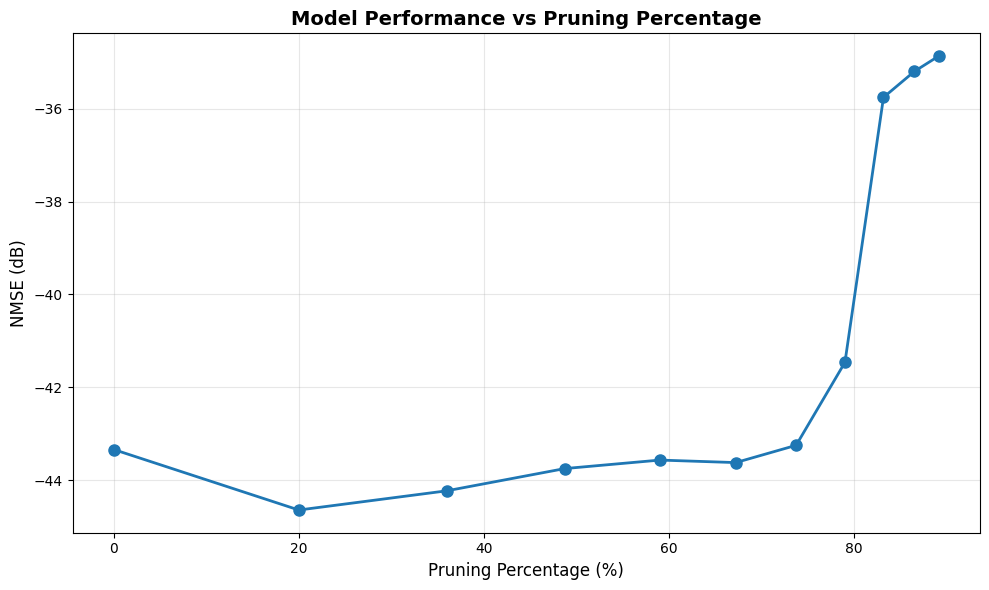

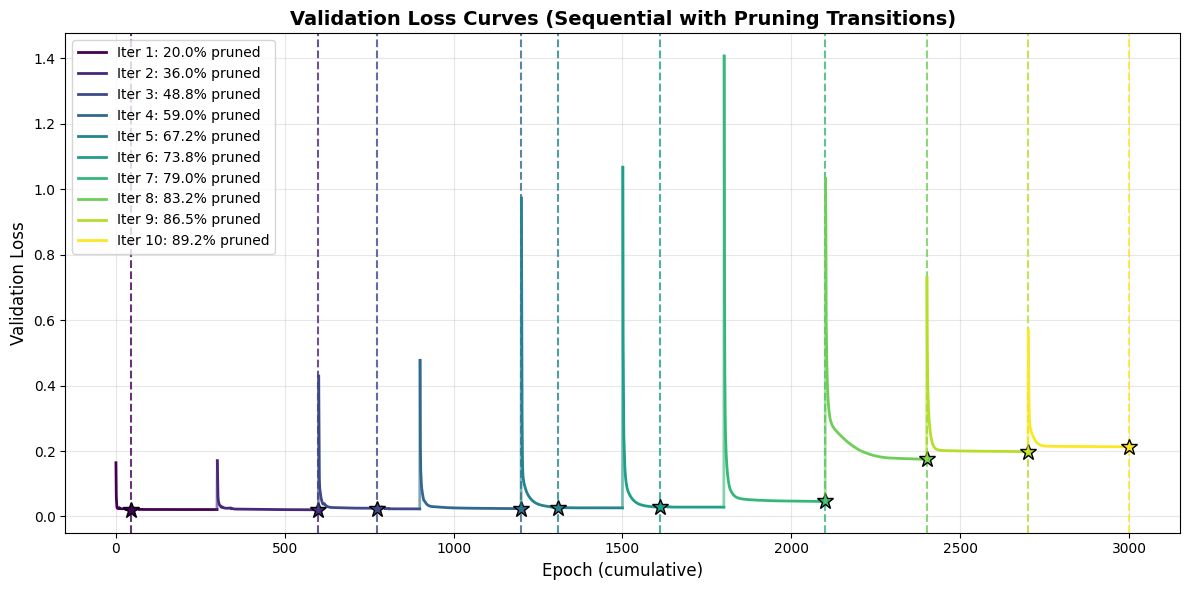

In [4]:
# Linearly prune the model
# Load the model
pntdnn_ideal_predistorted = PNTDNN_NeuralNetwork(num_memory_levels=15, model_type="OneLayerNetwork", forward_model=True, nn_file_path="pntdnn_ideal_predistorted_forward_model.pt")

pntdnn_ideal_pruning_experiment = LinearExperiment(
    nn_model= pntdnn_ideal_predistorted,
    num_prune_iterations=10,
    prune_amount=0.2,
    retrain_epochs=300,
    training_dataset=ideal_predistored_dataset.training_dataset,
    valid_dataset=ideal_predistored_dataset.validation_dataset,
    test_dataset=ideal_predistored_dataset.test_dataset,
    nmse_tolerance=-40
)
pntdnn_ideal_pruning_experiment.run()

# Save the best model
pntdnn_ideal_pruning_experiment.best_model.write_nn_to_file(file_path="pntdnn_ideal_predistorted_forward_model_linear_pruned.pt")

Using cuda device
Baseline NMSE          : -43.3384 dB
Tolerance              : +3.34 dB
NMSE must stay below   : -40.0000 dB
Initial prune fraction : 50.0%
Min prune fraction     : 1.0%
Max prune fraction     : 50.0%

Step 1  |  fraction = 50.00%
Pruning 50.00% of remaining weights...
Current sparsity: 50.00% of weights are zero
Retraining for 300 epochs...
Epoch  10/300  Loss=8.4871e-01  Valid Loss=8.1642e-02  LR=1.00e-03  NMSE=-39.0960 dB
Epoch  20/300  Loss=5.5260e-01  Valid Loss=4.8390e-02  LR=1.00e-03  NMSE=-41.3676 dB
Epoch  30/300  Loss=4.6270e-01  Valid Loss=3.8975e-02  LR=1.00e-03  NMSE=-42.3073 dB
Epoch  40/300  Loss=3.9875e-01  Valid Loss=3.5788e-02  LR=1.00e-03  NMSE=-42.6778 dB
Epoch  50/300  Loss=3.6957e-01  Valid Loss=3.3895e-02  LR=1.00e-03  NMSE=-42.9138 dB
Epoch  60/300  Loss=3.5791e-01  Valid Loss=3.3354e-02  LR=1.00e-03  NMSE=-42.9837 dB
Epoch  70/300  Loss=3.6058e-01  Valid Loss=3.1463e-02  LR=1.00e-03  NMSE=-43.2371 dB
Epoch  80/300  Loss=3.7218e-01  Valid Loss=3

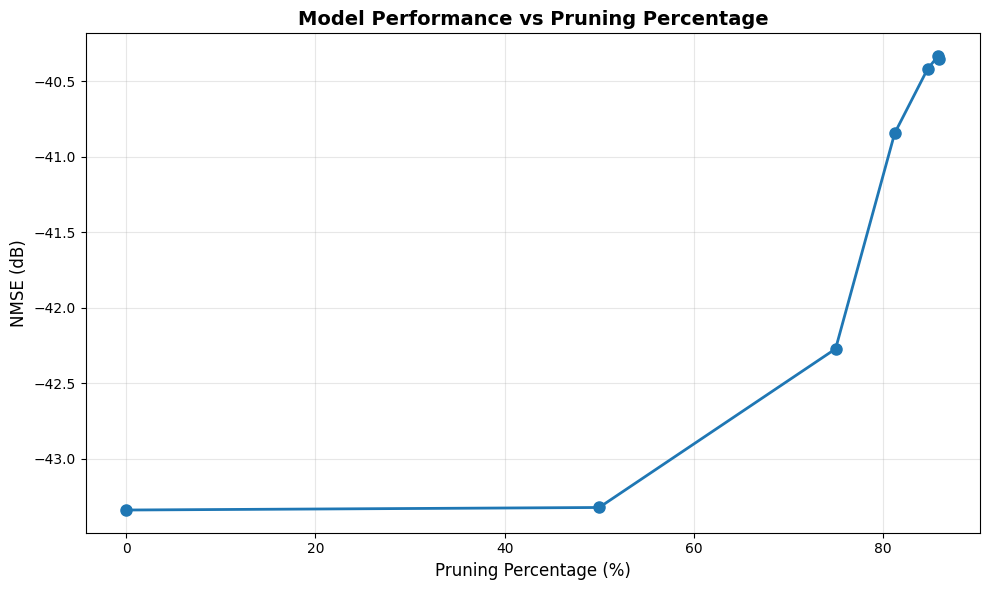

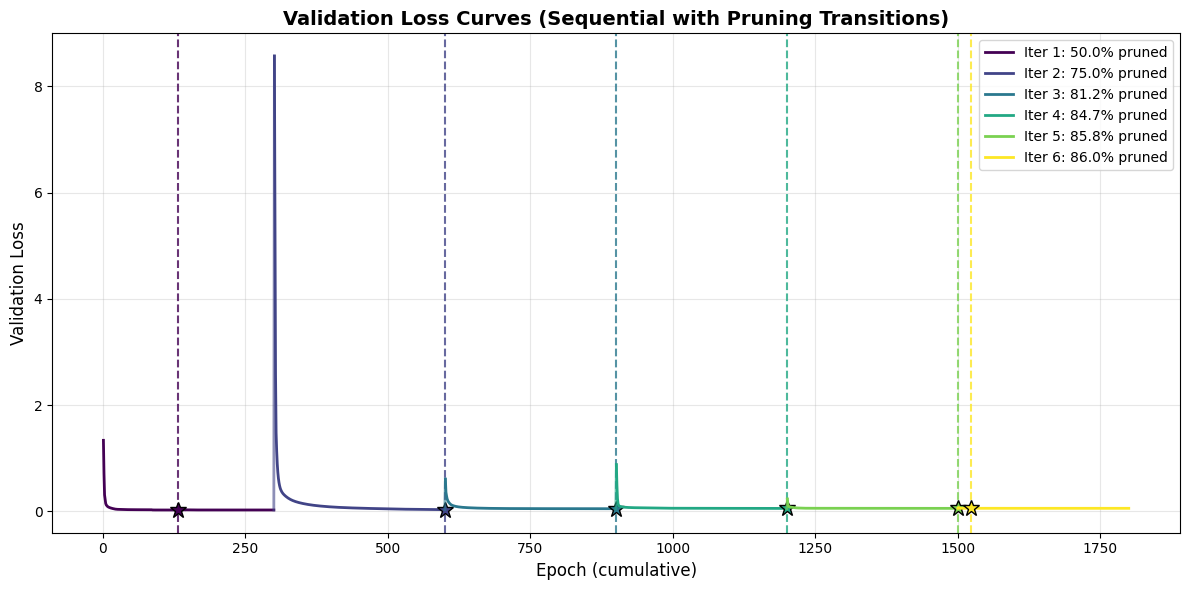

In [5]:
# Use adaptive pruning
pntdnn_ideal_predistorted = PNTDNN_NeuralNetwork(num_memory_levels=15, model_type="OneLayerNetwork", forward_model=True, nn_file_path="pntdnn_ideal_predistorted_forward_model.pt")

adaptive_pruning_experiment_PNTDNN = AdaptivePruningExperiment(
    nn_model=pntdnn_ideal_predistorted,
    retrain_epochs= 300,
    training_dataset = ideal_predistored_dataset.training_dataset,
    valid_dataset = ideal_predistored_dataset.validation_dataset,
    test_dataset = ideal_predistored_dataset.test_dataset,
    nmse_threshold = -40,
    initial_prune_fraction=0.5,
    min_prune_fraction=0.01,
    max_prune_fraction=0.5
)

adaptive_pruning_experiment_PNTDNN.run()

# Save the best model
adaptive_pruning_experiment_PNTDNN.best_model.write_nn_to_file(file_path="pntdnn_ideal_predistorted_forward_model_adaptive_pruned.pt")

In [6]:
# make .mat files for the best models, so they can be used in the future for physical testing
import scipy.io

num_memory_levels = 15
# Load original, adaptive and fixed pruning models
adaptive_model = PNTDNN_NeuralNetwork(num_memory_levels=15, model_type="OneLayerNetwork", forward_model=True, nn_file_path="pntdnn_ideal_predistorted_forward_model_adaptive_pruned.pt")
fixed_percent_model = PNTDNN_NeuralNetwork(num_memory_levels=15, model_type="OneLayerNetwork", forward_model=True, nn_file_path="pntdnn_ideal_predistorted_forward_model_linear_pruned.pt")
original_model = PNTDNN_NeuralNetwork(num_memory_levels=15, model_type="OneLayerNetwork", forward_model=True, nn_file_path="pntdnn_ideal_predistorted_forward_model.pt")

# Get the full input signal
full_input = ideal_predistored_dataset.input_data

# Generate outputs for each model
print("Generating outputs for each model...")
adaptive_output = adaptive_model.generate_model_output(full_input)
fixed_output = fixed_percent_model.generate_model_output(full_input)
original_output = original_model.generate_model_output(full_input)

# Save to .mat files with 'x' (input) and 'u' (output) naming convention
print("Saving .mat files...")
scipy.io.savemat('adaptive_pruned_output.mat', {'x1': full_input[num_memory_levels:], 'u': adaptive_output})
scipy.io.savemat('fixed_pruned_output.mat', {'x1': full_input[num_memory_levels:], 'u': fixed_output})
scipy.io.savemat('original_model_output.mat', {'x1': full_input[num_memory_levels:], 'u': original_output})

print("✓ Saved adaptive_pruned_output.mat")
print("✓ Saved fixed_pruned_output.mat")
print("✓ Saved original_model_output.mat")

Using cuda device
Using cuda device
Using cuda device
Generating outputs for each model...
Saving .mat files...
✓ Saved adaptive_pruned_output.mat
✓ Saved fixed_pruned_output.mat
✓ Saved original_model_output.mat


In [7]:
# Optionally save Volterra model output as well
volterra_output = volterra_forward_model.generate_model_output(full_input)
scipy.io.savemat('volterra_output.mat', {'x1': full_input[num_memory_levels:], 'u': volterra_output})
print("✓ Saved volterra_output.mat")

✓ Saved volterra_output.mat


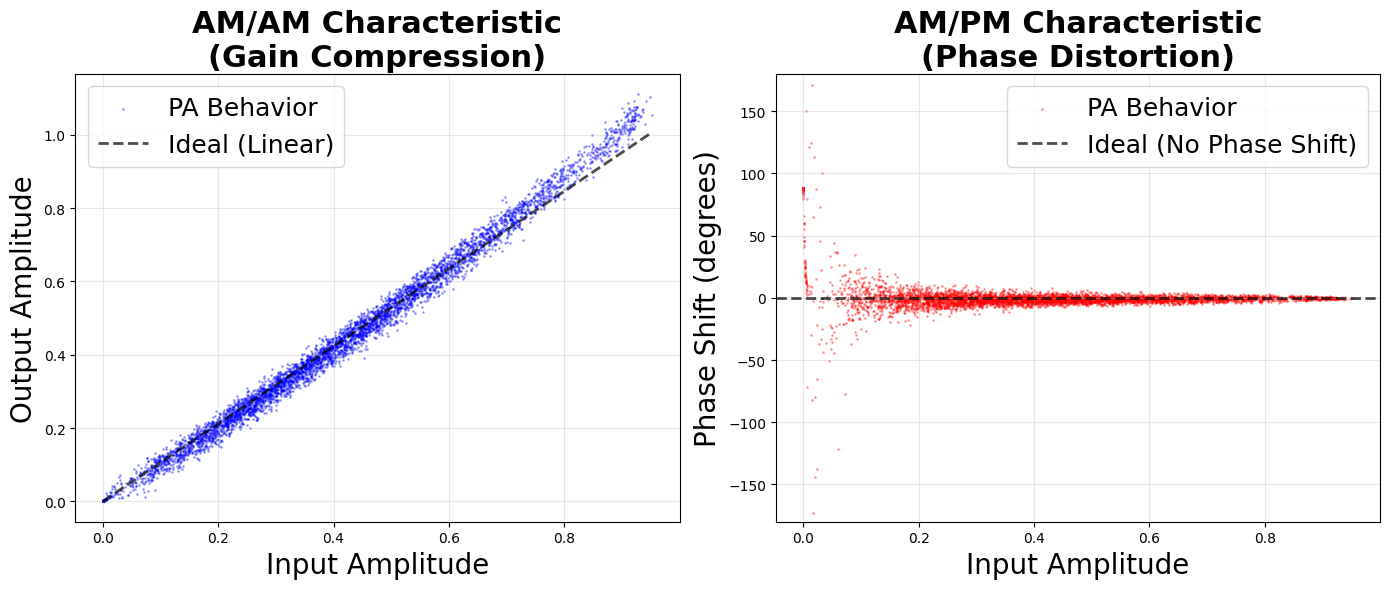


=== PA Characteristic Summary ===
Input amplitude range: 0.0000 to 0.9520
Output amplitude range: 0.0011 to 1.1103
Estimated small-signal gain: 1.0574
Phase distortion range: -173.13° to 171.23°


In [8]:
test = DataManager(num_training_points=50000, num_test_points=5000, num_validaiton_points=5000, filepath='fixed_pruned_output.mat')

test.plot_pa_characteristics()